In [1]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import json
import os
def ks_statistic(x, y):
    """Two-sample KS statistic D (numpy only)."""
    x = np.sort(x)
    y = np.sort(y)
    all_vals = np.sort(np.concatenate([x, y]))
    cdf_x = np.searchsorted(x, all_vals, side="right") / x.size
    cdf_y = np.searchsorted(y, all_vals, side="right") / y.size
    return float(np.max(np.abs(cdf_x - cdf_y)))

def wasserstein_1d(x, y):
    """1D Wasserstein-1 distance via quantiles (numpy only)."""
    x = np.sort(x)
    y = np.sort(y)
    n = min(x.size, y.size)
    if n == 0:
        return float("nan")
    # 동일한 quantile grid로 비교 (샘플 수 다를 때도 안정적)
    qs = (np.arange(n) + 0.5) / n
    xq = np.quantile(x, qs)
    yq = np.quantile(y, qs)
    return float(np.mean(np.abs(xq - yq)))

def js_divergence_hist(x, y, x_min, x_max, bins=60, eps=1e-12):
    """Jensen–Shannon divergence on histograms (numpy only)."""
    hx, edges = np.histogram(x, bins=bins, range=(x_min, x_max), density=False)
    hy, _     = np.histogram(y, bins=edges, density=False)

    px = hx.astype(float)
    py = hy.astype(float)
    px = px / (px.sum() + eps)
    py = py / (py.sum() + eps)

    m = 0.5 * (px + py)

    # KL(p||m) with safe eps
    px = np.clip(px, eps, 1.0)
    py = np.clip(py, eps, 1.0)
    m  = np.clip(m,  eps, 1.0)

    kl_xm = np.sum(px * np.log(px / m))
    kl_ym = np.sum(py * np.log(py / m))
    jsd = 0.5 * (kl_xm + kl_ym)
    return float(jsd)


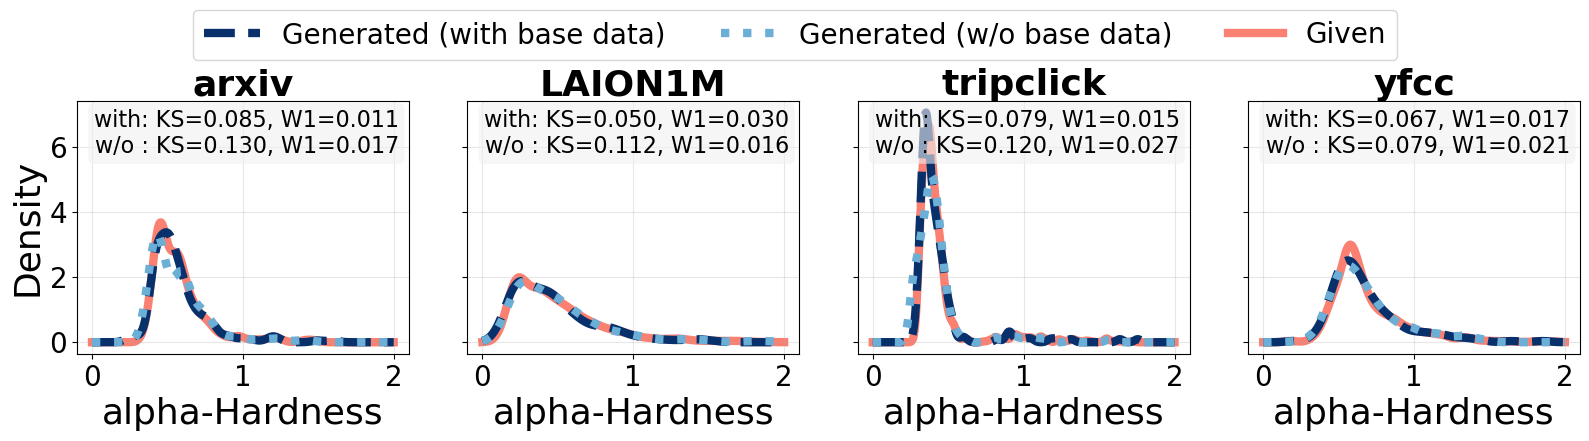

[Saved] /home/ec2-user/hybrid_hardness/fidelity_experiment/fidelity_hardnes_modi.pdf


In [26]:


# -------------------------------------------------
# 실험 설정
# -------------------------------------------------
datasets = ["arxiv",  "LAION1M", "tripclick", "yfcc"]
title_name_list = ["arxiv", "LAION1M", "tripclick", "yfcc"]
num_query_original_list = [200, 1000, 1000, 1000]

BASE_GEN_DIR  = "/home/ec2-user/hybrid_hardness/fidelity_experiment"
BASE_SEMI_DIR = "/home/ec2-user/hybrid_hardness/semi-real/filterbenchmark"

# -------------------------------------------------
# Plot 옵션
# -------------------------------------------------
FIX_X_RANGE = True
X_MIN, X_MAX = 0.0, 2.0
KDE_GRID = 500

# -------------------------------------------------
# KDE 구현 (scipy 없이)
# -------------------------------------------------
def silverman_bw(x):
    n = len(x)
    if n <= 1:
        return 1e-3
    std = np.std(x, ddof=1)
    iqr = np.percentile(x, 75) - np.percentile(x, 25)
    sigma = min(std, iqr / 1.349) if iqr > 0 else std
    bw = 0.9 * sigma * (n ** (-1 / 5))
    return float(bw) if bw > 1e-12 else 1e-3

def kde_1d(x, grid, bw):
    diff = (grid[:, None] - x[None, :]) / bw
    return np.exp(-0.5 * diff**2).mean(axis=1) / (bw * np.sqrt(2 * np.pi))

# -------------------------------------------------
# Similarity metrics (scipy 없이)
# -------------------------------------------------
def ks_statistic(x, y):
    """Two-sample KS statistic D (numpy only)."""
    x = np.asarray(x)
    y = np.asarray(y)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if x.size == 0 or y.size == 0:
        return float("nan")

    x = np.sort(x)
    y = np.sort(y)
    all_vals = np.sort(np.concatenate([x, y]))
    cdf_x = np.searchsorted(x, all_vals, side="right") / x.size
    cdf_y = np.searchsorted(y, all_vals, side="right") / y.size
    return float(np.max(np.abs(cdf_x - cdf_y)))

def wasserstein_1d(x, y):
    """1D Wasserstein-1 distance via quantiles (numpy only)."""
    x = np.asarray(x)
    y = np.asarray(y)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if x.size == 0 or y.size == 0:
        return float("nan")

    x = np.sort(x)
    y = np.sort(y)
    n = min(x.size, y.size)
    if n == 0:
        return float("nan")
    qs = (np.arange(n) + 0.5) / n
    xq = np.quantile(x, qs)
    yq = np.quantile(y, qs)
    return float(np.mean(np.abs(xq - yq)))

# -------------------------------------------------
# File load helpers
# -------------------------------------------------
def load_txt_vals(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"[Missing] {path}")
    vals = np.loadtxt(path, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        raise ValueError(f"[Empty/Invalid] No finite values in {path}")
    return vals

def load_given_vals(json_path):
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"[Missing] {json_path}")
    with open(json_path, "r", encoding="utf-8") as f:
        data_json = json.load(f)
    vals = np.array([d["Post_Hardness"] for d in data_json], dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        raise ValueError(f"[Empty/Invalid] No finite Post_Hardness in {json_path}")
    return vals

# -------------------------------------------------
# Figure
# -------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), sharey=True)

for ax, semi_real_dataset_name, num_query_original, title_name in zip(
    axes, datasets, num_query_original_list, title_name_list
):
    # -----------------------------
    # 경로 (with payload / wo payload / given)
    # -----------------------------
    txt_path_with = (
        f"{BASE_GEN_DIR}/{semi_real_dataset_name}_generated/"
        f"mid_format/post_hardness.txt"
    )
    txt_path_wo = (
        f"{BASE_GEN_DIR}/{semi_real_dataset_name}_generated_wo_payload/"
        f"mid_format/post_hardness.txt"
    )
    json_path = (
        f"{BASE_SEMI_DIR}/{semi_real_dataset_name}/hardness/"
        f"hardness_v5.1_{num_query_original}.json"
    )

    # -----------------------------
    # 데이터 로딩
    # -----------------------------
    vals_with = load_txt_vals(txt_path_with)
    vals_wo   = load_txt_vals(txt_path_wo)
    vals_given = load_given_vals(json_path)

    # -----------------------------
    # Grid
    # -----------------------------
    x_min = X_MIN if FIX_X_RANGE else min(vals_with.min(), vals_wo.min(), vals_given.min())
    x_max = X_MAX if FIX_X_RANGE else max(vals_with.max(), vals_wo.max(), vals_given.max())
    grid = np.linspace(x_min, x_max, KDE_GRID)

    # -----------------------------
    # KDE
    # -----------------------------
    kde_with  = kde_1d(vals_with,  grid, silverman_bw(vals_with))
    kde_wo    = kde_1d(vals_wo,    grid, silverman_bw(vals_wo))
    kde_given = kde_1d(vals_given, grid, silverman_bw(vals_given))

    # -----------------------------
    # Plot
    # -----------------------------
    ax.plot(
        grid, kde_with,
        linewidth=6, linestyle="--",
        label="Generated (with base data)",
        color="#08306B", zorder=2
    )
    ax.plot(
        grid, kde_wo,
        linewidth=6, linestyle=":",
        label="Generated (w/o base data)",
        color="#6BAED6", zorder=3
    )
    ax.plot(
        grid, kde_given,
        linewidth=6, linestyle="-",
        label="Given",
        color="salmon", zorder=1
    )

    ax.set_xlabel("alpha-Hardness", fontsize=26)
    ax.grid(alpha=0.3)

    # tick 크기
    ax.tick_params(axis="x", labelsize=20)
    ax.tick_params(axis="y", labelsize=20)

    # 패널 라벨 (상단 중앙)
    ax.text(
        0.5, 1.13,
        title_name,
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=26,
        fontweight="bold",
    )

    # -----------------------------
    # Similarity scores (vs Given)
    # -----------------------------
    ks_w  = ks_statistic(vals_with, vals_given)
    w1_w  = wasserstein_1d(vals_with, vals_given)

    ks_wo = ks_statistic(vals_wo, vals_given)
    w1_wo = wasserstein_1d(vals_wo, vals_given)

    score_text = (
        f"with: KS={ks_w:.3f}, W1={w1_w:.3f}\n"
        f"w/o : KS={ks_wo:.3f}, W1={w1_wo:.3f}"
    )

    ax.text(
        0.97, 0.97,
        score_text,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=16,
        bbox=dict(facecolor="#F0F0F0", edgecolor="none", boxstyle="round,pad=0.25",alpha=0.6),
    )

# -------------------------------------------------
# 공통 Y / Legend
# -------------------------------------------------
axes[0].set_ylabel("Density", fontsize=26)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.05),
    fontsize=20,
    frameon=True,
    # facecolor="#F0F0F0",
    # edgecolor="none",
)



plt.tight_layout(rect=[0, 0.05, 1, 0.95])

out_path = f"{BASE_GEN_DIR}/fidelity_hardnes_modi.pdf"
plt.savefig(
    out_path,
    dpi=150,
    bbox_inches="tight",
    pad_inches=0.25,
)
plt.show()

print(f"[Saved] {out_path}")


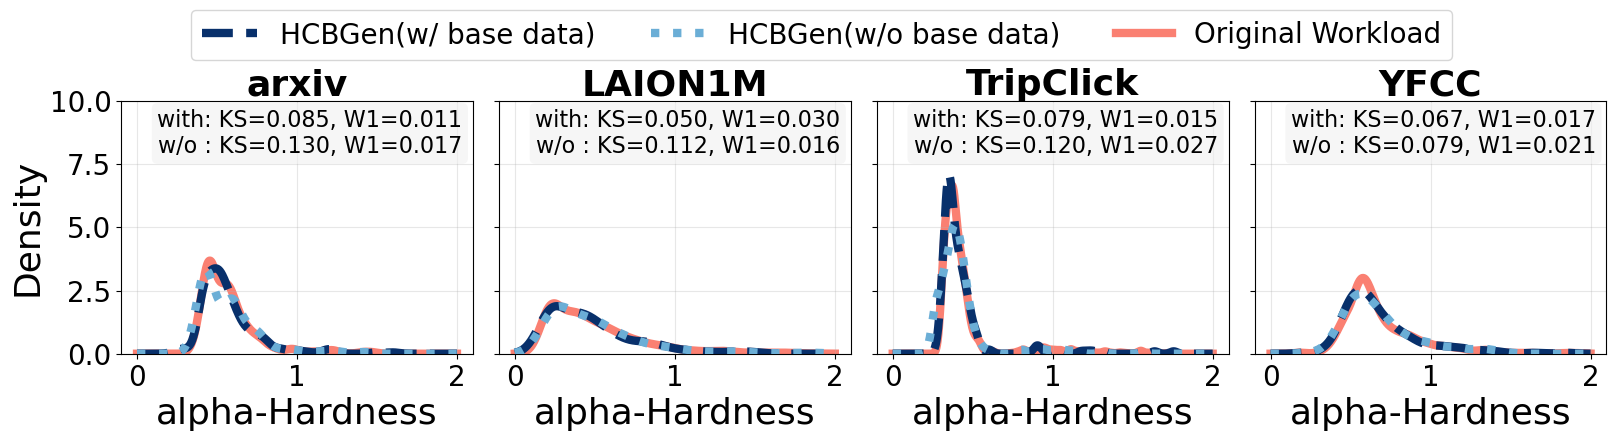

[Saved] /home/ec2-user/hybrid_hardness/fidelity_experiment/fidelity_hardnes_modi.pdf


In [34]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 실험 설정
# -------------------------------------------------
datasets = ["arxiv", "LAION1M", "tripclick", "yfcc"]
title_name_list = ["arxiv", "LAION1M", "TripClick", "YFCC"]
num_query_original_list = [200, 1000, 1000, 1000]

BASE_GEN_DIR  = "/home/ec2-user/hybrid_hardness/fidelity_experiment"
BASE_SEMI_DIR = "/home/ec2-user/hybrid_hardness/semi-real/filterbenchmark"

# -------------------------------------------------
# Plot 옵션
# -------------------------------------------------
FIX_X_RANGE = True
X_MIN, X_MAX = 0.0, 2.0
KDE_GRID = 500

# Y축 고정 옵션
FIX_Y_RANGE = True
Y_MIN, Y_MAX = 0.0, 10.0  # 필요에 맞게 조정

# 서브플롯 간격 옵션
WSPACE = 0.03   # 가로 간격
HSPACE = 0.30   # 세로 간격 (여기선 1행이라 의미 거의 없음)

# -------------------------------------------------
# KDE 구현 (scipy 없이)
# -------------------------------------------------
def silverman_bw(x):
    n = len(x)
    if n <= 1:
        return 1e-3
    std = np.std(x, ddof=1)
    iqr = np.percentile(x, 75) - np.percentile(x, 25)
    sigma = min(std, iqr / 1.349) if iqr > 0 else std
    bw = 0.9 * sigma * (n ** (-1 / 5))
    return float(bw) if bw > 1e-12 else 1e-3

def kde_1d(x, grid, bw):
    diff = (grid[:, None] - x[None, :]) / bw
    return np.exp(-0.5 * diff**2).mean(axis=1) / (bw * np.sqrt(2 * np.pi))

# -------------------------------------------------
# Similarity metrics (scipy 없이)
# -------------------------------------------------
def ks_statistic(x, y):
    """Two-sample KS statistic D (numpy only)."""
    x = np.asarray(x)
    y = np.asarray(y)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if x.size == 0 or y.size == 0:
        return float("nan")

    x = np.sort(x)
    y = np.sort(y)
    all_vals = np.sort(np.concatenate([x, y]))
    cdf_x = np.searchsorted(x, all_vals, side="right") / x.size
    cdf_y = np.searchsorted(y, all_vals, side="right") / y.size
    return float(np.max(np.abs(cdf_x - cdf_y)))

def wasserstein_1d(x, y):
    """1D Wasserstein-1 distance via quantiles (numpy only)."""
    x = np.asarray(x)
    y = np.asarray(y)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if x.size == 0 or y.size == 0:
        return float("nan")

    x = np.sort(x)
    y = np.sort(y)
    n = min(x.size, y.size)
    if n == 0:
        return float("nan")
    qs = (np.arange(n) + 0.5) / n
    xq = np.quantile(x, qs)
    yq = np.quantile(y, qs)
    return float(np.mean(np.abs(xq - yq)))

# -------------------------------------------------
# File load helpers
# -------------------------------------------------
def load_txt_vals(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"[Missing] {path}")
    vals = np.loadtxt(path, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        raise ValueError(f"[Empty/Invalid] No finite values in {path}")
    return vals

def load_given_vals(json_path):
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"[Missing] {json_path}")
    with open(json_path, "r", encoding="utf-8") as f:
        data_json = json.load(f)
    vals = np.array([d["Post_Hardness"] for d in data_json], dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        raise ValueError(f"[Empty/Invalid] No finite Post_Hardness in {json_path}")
    return vals

# -------------------------------------------------
# Figure
# -------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), sharey=True)

for ax, semi_real_dataset_name, num_query_original, title_name in zip(
    axes, datasets, num_query_original_list, title_name_list
):
    # -----------------------------
    # 경로 (with payload / wo payload / given)
    # -----------------------------
    txt_path_with = (
        f"{BASE_GEN_DIR}/{semi_real_dataset_name}_generated/"
        f"mid_format/post_hardness.txt"
    )
    txt_path_wo = (
        f"{BASE_GEN_DIR}/{semi_real_dataset_name}_generated_wo_payload/"
        f"mid_format/post_hardness.txt"
    )
    json_path = (
        f"{BASE_SEMI_DIR}/{semi_real_dataset_name}/hardness/"
        f"hardness_v5.1_{num_query_original}.json"
    )

    # -----------------------------
    # 데이터 로딩
    # -----------------------------
    vals_with = load_txt_vals(txt_path_with)
    vals_wo   = load_txt_vals(txt_path_wo)
    vals_given = load_given_vals(json_path)

    # -----------------------------
    # Grid
    # -----------------------------
    if FIX_X_RANGE:
        x_min, x_max = X_MIN, X_MAX
    else:
        x_min = min(vals_with.min(), vals_wo.min(), vals_given.min())
        x_max = max(vals_with.max(), vals_wo.max(), vals_given.max())

    grid = np.linspace(x_min, x_max, KDE_GRID)

    # -----------------------------
    # KDE
    # -----------------------------
    kde_with  = kde_1d(vals_with,  grid, silverman_bw(vals_with))
    kde_wo    = kde_1d(vals_wo,    grid, silverman_bw(vals_wo))
    kde_given = kde_1d(vals_given, grid, silverman_bw(vals_given))

    # -----------------------------
    # Plot
    # -----------------------------
    ax.plot(
        grid, kde_with,
        linewidth=6, linestyle="--",
        label="HCBGen(w/ base data)",
        color="#08306B", zorder=2
    )
    ax.plot(
        grid, kde_wo,
        linewidth=6, linestyle=":",
        label="HCBGen(w/o base data)",
        color="#6BAED6", zorder=3
    )
    ax.plot(
        grid, kde_given,
        linewidth=6, linestyle="-",
        label="Original Workload",
        color="salmon", zorder=1
    )

    ax.set_xlabel("alpha-Hardness", fontsize=26)
    ax.grid(alpha=0.3)

    # X/Y tick 크기
    ax.tick_params(axis="x", labelsize=20)
    ax.tick_params(axis="y", labelsize=20)

    # 패널 라벨 (상단 중앙)
    ax.text(
        0.5, 1.13,
        title_name,
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=26,
        fontweight="bold",
    )

    # Y축 범위 고정
    if FIX_Y_RANGE:
        ax.set_ylim(Y_MIN, Y_MAX)

    # -----------------------------
    # Similarity scores (vs Given)
    # -----------------------------
    ks_w  = ks_statistic(vals_with, vals_given)
    w1_w  = wasserstein_1d(vals_with, vals_given)

    ks_wo = ks_statistic(vals_wo, vals_given)
    w1_wo = wasserstein_1d(vals_wo, vals_given)

    score_text = (
        f"with: KS={ks_w:.3f}, W1={w1_w:.3f}\n"
        f"w/o : KS={ks_wo:.3f}, W1={w1_wo:.3f}"
    )

    ax.text(
        0.97, 0.97,
        score_text,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=16,
        bbox=dict(
            facecolor="#F0F0F0",
            edgecolor="none",
            boxstyle="round,pad=0.25",
            alpha=0.6,
        ),
    )

# -------------------------------------------------
# 공통 Y / Legend
# -------------------------------------------------
axes[0].set_ylabel("Density", fontsize=26)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.05),
    fontsize=20,
    frameon=True,
)

# 서브플롯 간격 조절
plt.subplots_adjust(wspace=WSPACE, hspace=HSPACE)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])

out_path = f"{BASE_GEN_DIR}/fidelity_hardnes_modi.pdf"
plt.savefig(
    out_path,
    dpi=150,
    bbox_inches="tight",
    pad_inches=0.25,
)
plt.show()

print(f"[Saved] {out_path}")


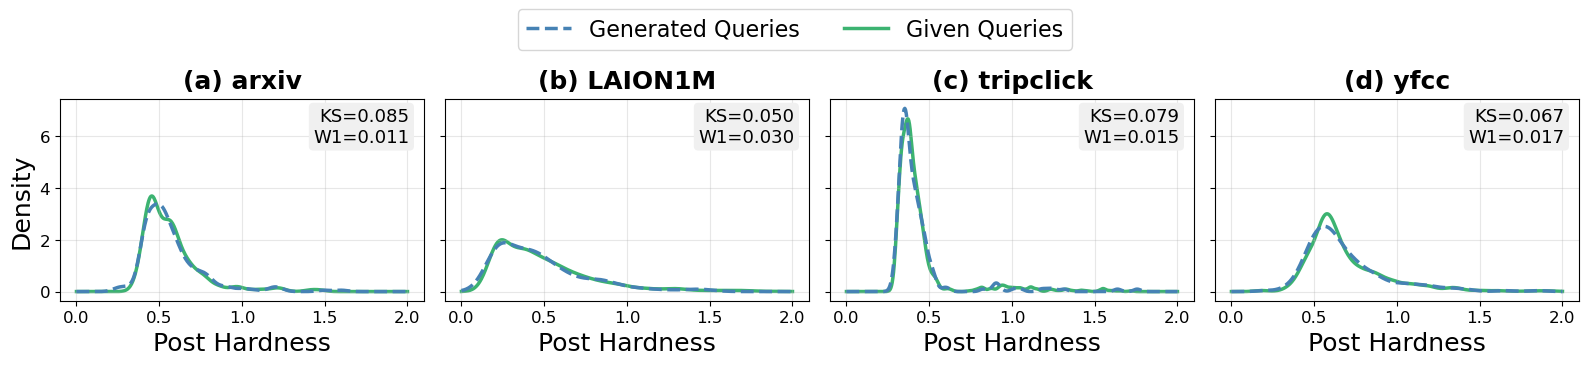

[Saved] /home/ec2-user/hybrid_hardness/fidelity_experiment/hardness_kde_4datasets.png


In [ ]:


BASE_GEN_DIR  = "/home/ec2-user/hybrid_hardness/fidelity_experiment"
BASE_SEMI_DIR = "/home/ec2-user/hybrid_hardness/semi-real/filterbenchmark"

# -------------------------------------------------
# Plot 옵션
# -------------------------------------------------
FIX_X_RANGE = True
X_MIN, X_MAX = 0.0, 2.0
KDE_GRID = 500

# -------------------------------------------------
# KDE 구현 (scipy 없이)
# -------------------------------------------------
def silverman_bw(x):
    n = len(x)
    std = np.std(x, ddof=1)
    iqr = np.percentile(x, 75) - np.percentile(x, 25)
    sigma = min(std, iqr / 1.349) if iqr > 0 else std
    return 0.9 * sigma * (n ** (-1 / 5))

def kde_1d(x, grid, bw):
    diff = (grid[:, None] - x[None, :]) / bw
    return np.exp(-0.5 * diff**2).mean(axis=1) / (bw * np.sqrt(2 * np.pi))

# -------------------------------------------------
# Figure
# -------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, semi_real_dataset_name, num_query_original, title_name in zip(axes, datasets, num_query_original_list, title_name_list):
    # -----------------------------
    # 경로
    # -----------------------------
    txt_path = (
        f"{BASE_GEN_DIR}/{semi_real_dataset_name}_generated/"
        f"mid_format/post_hardness.txt"
    )
    json_path = (
        f"{BASE_SEMI_DIR}/{semi_real_dataset_name}/hardness/"
        f"hardness_v5.1_{num_query_original}.json"
    )

    # -----------------------------
    # 데이터 로딩
    # -----------------------------
    vals_txt = np.loadtxt(txt_path, dtype=float)
    vals_txt = vals_txt[np.isfinite(vals_txt)]

    with open(json_path, "r", encoding="utf-8") as f:
        data_json = json.load(f)
    vals_json = np.array([d["Post_Hardness"] for d in data_json], dtype=float)
    vals_json = vals_json[np.isfinite(vals_json)]

    # -----------------------------
    # Grid
    # -----------------------------
    x_min = X_MIN if FIX_X_RANGE else min(vals_txt.min(), vals_json.min())
    x_max = X_MAX if FIX_X_RANGE else max(vals_txt.max(), vals_json.max())
    grid = np.linspace(x_min, x_max, KDE_GRID)

    # -----------------------------
    # KDE
    # -----------------------------
    kde_txt  = kde_1d(vals_txt,  grid, silverman_bw(vals_txt))
    kde_json = kde_1d(vals_json, grid, silverman_bw(vals_json))

    # -----------------------------
    # Plot
    # -----------------------------
    ax.plot(
        grid, kde_txt,
        linewidth=2.5, linestyle="--",
        label="Generated Queries", zorder=2,
        color="steelblue"
    )
    ax.plot(
        grid, kde_json,
        linewidth=2.5, linestyle="-",
        label="Given Queries", zorder=1,
        color="mediumseagreen"
    )

    ax.set_xlabel("Post Hardness", fontsize=18)
    ax.grid(alpha=0.3)

    # ▼ title을 아래로 (subplot 하단 중앙)
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    ax.text(
        0.5, 1.15,
        title_name,
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=18,
        fontweight="bold",
    )
    # -----------------------------
    # Similarity scores (Generated vs Semi-real)
    # -----------------------------
    ks  = ks_statistic(vals_txt, vals_json)
    w1  = wasserstein_1d(vals_txt, vals_json)
    jsd = js_divergence_hist(vals_txt, vals_json, x_min, x_max, bins=60)

    # score_text = f"KS={ks:.3f}\nW1={w1:.3f}\nJSD={jsd:.3f}"
    score_text = f"KS={ks:.3f}\nW1={w1:.3f}"

    ax.text(
        0.96, 0.96,
        score_text,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=13,
        bbox=dict(facecolor="#F0F0F0", edgecolor="none", boxstyle="round,pad=0.25"),
    )


# -------------------------------------------------
# 공통 Y / Legend
# -------------------------------------------------
axes[0].set_ylabel("Density", fontsize="18")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.05),
    fontsize="16"
)

plt.tight_layout(rect=[0, 0.12, 1, 0.95])



out_path = f"{BASE_GEN_DIR}/hardness_kde_4datasets.png"
# plt.savefig(out_path, dpi=150)
plt.show()

print(f"[Saved] {out_path}")


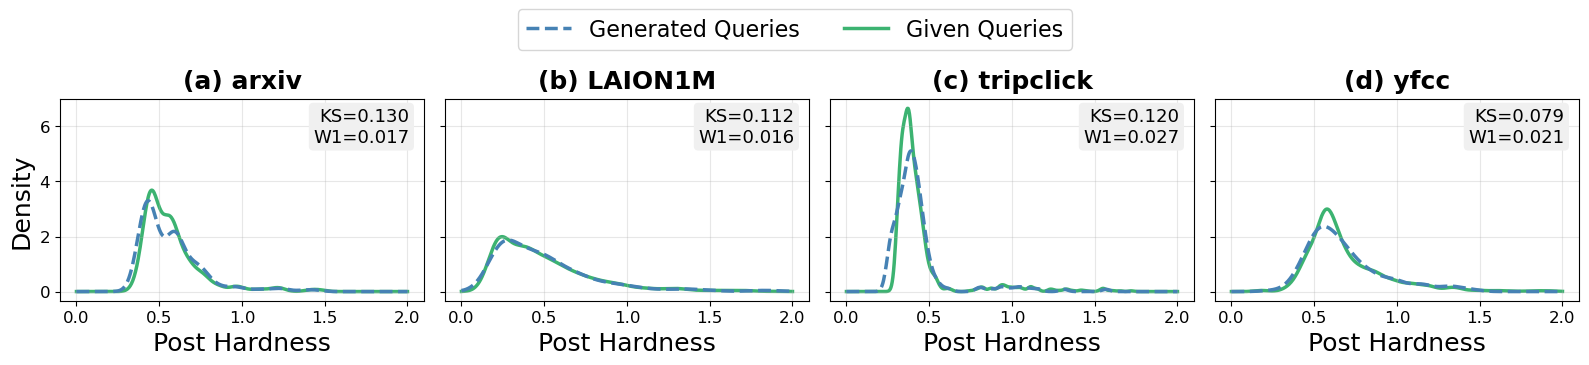

[Saved] /home/ec2-user/hybrid_hardness/fidelity_experiment/hardness_kde_4datasets.png


In [3]:
BASE_GEN_DIR  = "/home/ec2-user/hybrid_hardness/fidelity_experiment"
BASE_SEMI_DIR = "/home/ec2-user/hybrid_hardness/semi-real/filterbenchmark"

# -------------------------------------------------
# Plot 옵션
# -------------------------------------------------
FIX_X_RANGE = True
X_MIN, X_MAX = 0.0, 2.0
KDE_GRID = 500

# -------------------------------------------------
# KDE 구현 (scipy 없이)
# -------------------------------------------------
def silverman_bw(x):
    n = len(x)
    std = np.std(x, ddof=1)
    iqr = np.percentile(x, 75) - np.percentile(x, 25)
    sigma = min(std, iqr / 1.349) if iqr > 0 else std
    return 0.9 * sigma * (n ** (-1 / 5))

def kde_1d(x, grid, bw):
    diff = (grid[:, None] - x[None, :]) / bw
    return np.exp(-0.5 * diff**2).mean(axis=1) / (bw * np.sqrt(2 * np.pi))

# -------------------------------------------------
# Figure
# -------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, semi_real_dataset_name, num_query_original, title_name in zip(axes, datasets, num_query_original_list, title_name_list):
    # -----------------------------
    # 경로
    # -----------------------------
    txt_path = (
        f"{BASE_GEN_DIR}/{semi_real_dataset_name}_generated_wo_payload/"
        f"mid_format/post_hardness.txt"
    )
    json_path = (
        f"{BASE_SEMI_DIR}/{semi_real_dataset_name}/hardness/"
        f"hardness_v5.1_{num_query_original}.json"
    )

    # -----------------------------
    # 데이터 로딩
    # -----------------------------
    vals_txt = np.loadtxt(txt_path, dtype=float)
    vals_txt = vals_txt[np.isfinite(vals_txt)]

    with open(json_path, "r", encoding="utf-8") as f:
        data_json = json.load(f)
    vals_json = np.array([d["Post_Hardness"] for d in data_json], dtype=float)
    vals_json = vals_json[np.isfinite(vals_json)]

    # -----------------------------
    # Grid
    # -----------------------------
    x_min = X_MIN if FIX_X_RANGE else min(vals_txt.min(), vals_json.min())
    x_max = X_MAX if FIX_X_RANGE else max(vals_txt.max(), vals_json.max())
    grid = np.linspace(x_min, x_max, KDE_GRID)

    # -----------------------------
    # KDE
    # -----------------------------
    kde_txt  = kde_1d(vals_txt,  grid, silverman_bw(vals_txt))
    kde_json = kde_1d(vals_json, grid, silverman_bw(vals_json))

    # -----------------------------
    # Plot
    # -----------------------------
    ax.plot(
        grid, kde_txt,
        linewidth=2.5, linestyle="--",
        label="Generated Queries", zorder=2,
        color="steelblue"
    )
    ax.plot(
        grid, kde_json,
        linewidth=2.5, linestyle="-",
        label="Given Queries", zorder=1,
        color="mediumseagreen"
    )

    ax.set_xlabel("Post Hardness", fontsize=18)
    ax.grid(alpha=0.3)

    # ▼ title을 아래로 (subplot 하단 중앙)
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    ax.text(
        0.5, 1.15,
        title_name,
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=18,
        fontweight="bold",
    )
    # -----------------------------
    # Similarity scores (Generated vs Semi-real)
    # -----------------------------
    ks  = ks_statistic(vals_txt, vals_json)
    w1  = wasserstein_1d(vals_txt, vals_json)
    jsd = js_divergence_hist(vals_txt, vals_json, x_min, x_max, bins=60)

    # score_text = f"KS={ks:.3f}\nW1={w1:.3f}\nJSD={jsd:.3f}"
    score_text = f"KS={ks:.3f}\nW1={w1:.3f}"

    ax.text(
        0.96, 0.96,
        score_text,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=13,
        bbox=dict(facecolor="#F0F0F0", edgecolor="none", boxstyle="round,pad=0.25"),
    )


# -------------------------------------------------
# 공통 Y / Legend
# -------------------------------------------------
axes[0].set_ylabel("Density", fontsize="18")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.05),
    fontsize="16"
)

plt.tight_layout(rect=[0, 0.12, 1, 0.95])



out_path = f"{BASE_GEN_DIR}/hardness_kde_4datasets.png"
# plt.savefig(out_path, dpi=150)
plt.show()

print(f"[Saved] {out_path}")


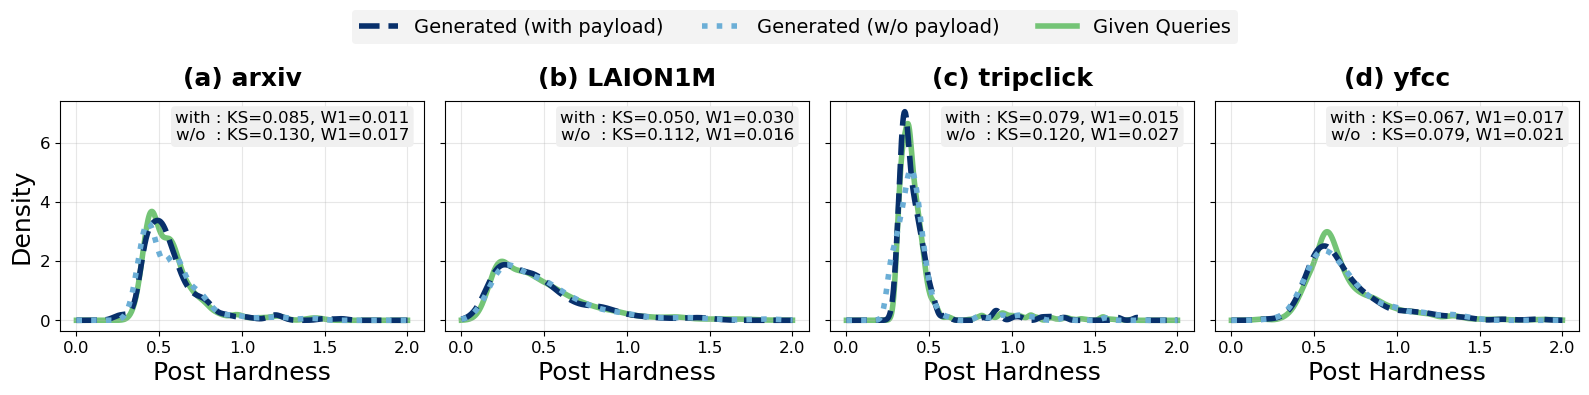

[Saved] /home/ec2-user/hybrid_hardness/fidelity_experiment/fidelity_hardness.pdf


[Info] Loaded 200 hardness values from:
       /home/ec2-user/hybrid_hardness/fidelity_experiment/arxiv_generated/mid_format/post_hardness.txt
[Info] After filtering non-finite: 200 values

[Stats]
  min        : 0.251701
  max        : 1.600361
  mean       : 0.571839
  std        : 0.190623
  p10 / p50 / p90 : 0.410585 / 0.526979 / 0.773496
  trimmed range (p10~p90): [0.410585, 0.773496]


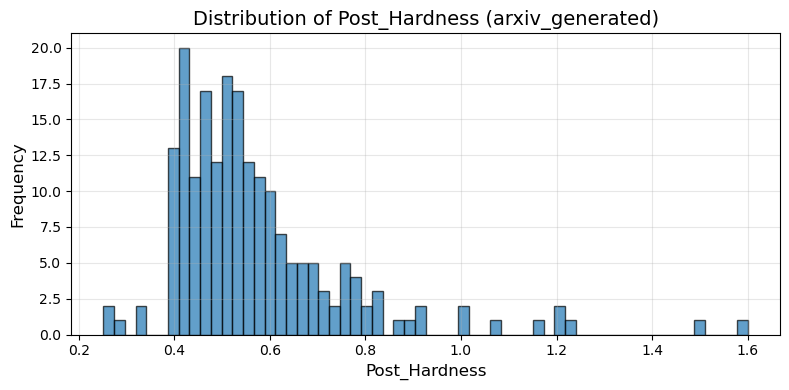

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os

# -------------------------------------------------
# 1) 파일 경로
# -------------------------------------------------
path = "/home/ec2-user/hybrid_hardness/fidelity_experiment/arxiv_generated/mid_format/post_hardness.txt"

if not os.path.exists(path):
    raise FileNotFoundError(f"File not found: {path}")

# -------------------------------------------------
# 2) 데이터 로드
# -------------------------------------------------
vals = np.loadtxt(path, dtype=float)

print(f"[Info] Loaded {len(vals):,} hardness values from:")
print(f"       {path}")

# NaN / inf 제거 (혹시 모를 방어)
vals = vals[np.isfinite(vals)]
print(f"[Info] After filtering non-finite: {len(vals):,} values")

# -------------------------------------------------
# 3) 기본 통계 + trimmed range (10% ~ 90%)
# -------------------------------------------------
mean = np.mean(vals)
std  = np.std(vals)
p10  = np.percentile(vals, 10)
p50  = np.percentile(vals, 50)
p90  = np.percentile(vals, 90)
vmin = np.min(vals)
vmax = np.max(vals)

print("\n[Stats]")
print(f"  min        : {vmin:.6f}")
print(f"  max        : {vmax:.6f}")
print(f"  mean       : {mean:.6f}")
print(f"  std        : {std:.6f}")
print(f"  p10 / p50 / p90 : {p10:.6f} / {p50:.6f} / {p90:.6f}")
print(f"  trimmed range (p10~p90): [{p10:.6f}, {p90:.6f}]")

# -------------------------------------------------
# 4) 히스토그램 플롯
# -------------------------------------------------
plt.figure(figsize=(8, 4))

# 필요하면 bin range/개수 조정
bin_edges = np.linspace(np.min(vals), np.max(vals), 61)

plt.hist(
    vals,
    bins=bin_edges,
    alpha=0.7,
    edgecolor="black",
)

plt.title("Distribution of Post_Hardness (arxiv_generated)", fontsize=14)
plt.xlabel("Post_Hardness", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()

out_png = os.path.join(os.path.dirname(path), "post_hardness_distribution.png")
# plt.savefig(out_png, dpi=150)
plt.show()


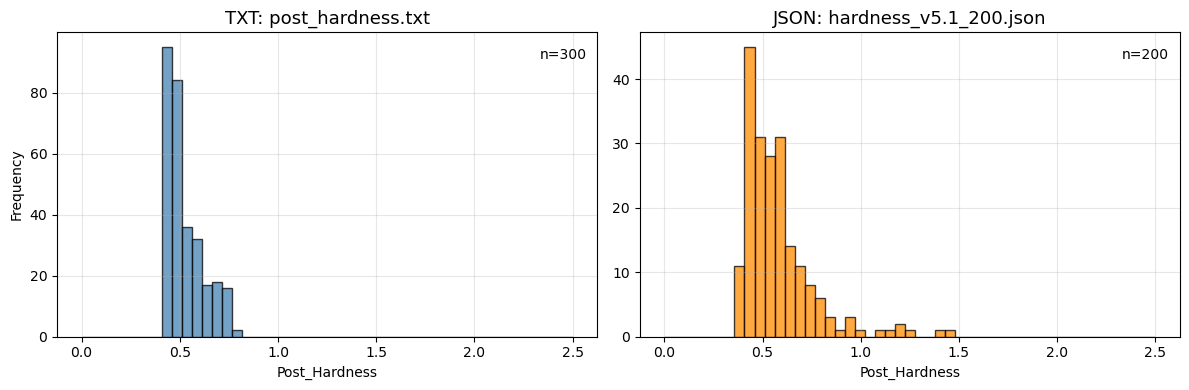

[Output] Saved → /home/ec2-user/hybrid_hardness/fidelity_experiment/arxiv_generated/mid_format/hardness_comparison.png

====================== SUMMARY STATISTICS ======================
                 TXT (post_hardness.txt)
     count : 300.000000
      mean : 0.523032
       std : 0.093057
       min : 0.408642
       25% : 0.451182
    median : 0.489903
       75% : 0.573748
       max : 0.801189
       iqr : 0.122566

                 JSON (hardness_v5.1_200.json)
     count : 200.000000
      mean : 0.574522
       std : 0.180662
       min : 0.360121
       25% : 0.454761
    median : 0.533634
       75% : 0.621032
       max : 1.468954
       iqr : 0.166271

==================== DIFFERENCE (TXT - JSON) ====================
     count : 100.000000
      mean : -0.051490
       std : -0.087605
       min : 0.048522
       25% : -0.003579
    median : -0.043731
       75% : -0.047284
       max : -0.667765
       iqr : -0.043706


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os

# -------------------------------------------------
# 경로 설정
# -------------------------------------------------
txt_path = "/home/ec2-user/hybrid_hardness/fidelity_experiment/arxiv_generated/mid_format/post_hardness.txt"
json_path = "/home/ec2-user/hybrid_hardness/semi-real/filterbenchmark/arxiv/hardness/hardness_v5.1_200.json"

# -------------------------------------------------
# 1) TXT hardness 로딩
# -------------------------------------------------
if not os.path.exists(txt_path):
    raise FileNotFoundError(txt_path)

vals_txt = np.loadtxt(txt_path, dtype=float)
vals_txt = vals_txt[np.isfinite(vals_txt)]  # 방어적 필터

# -------------------------------------------------
# 2) JSON hardness 로딩
# -------------------------------------------------
if not os.path.exists(json_path):
    raise FileNotFoundError(json_path)

with open(json_path, "r", encoding="utf-8") as f:
    data_json = json.load(f)

vals_json = np.array([item["Post_Hardness"] for item in data_json], dtype=float)

# -------------------------------------------------
# 3) 통계 계산 함수
# -------------------------------------------------
def get_stats(arr):
    return {
        "count": len(arr),
        "mean": np.mean(arr),
        "std": np.std(arr),
        "min": np.min(arr),
        "25%": np.percentile(arr, 25),
        "median": np.median(arr),
        "75%": np.percentile(arr, 75),
        "max": np.max(arr),
        "iqr": np.percentile(arr, 75) - np.percentile(arr, 25)
    }

stats_txt = get_stats(vals_txt)
stats_json = get_stats(vals_json)

# -------------------------------------------------
# 4) 플롯 준비
# -------------------------------------------------
plt.figure(figsize=(12, 4))

global_min = min(vals_txt.min(), vals_json.min())
global_max = max(vals_txt.max(), vals_json.max())
bin_edges = np.linspace(0.0, 2.5, 50)

# Subplot 1: TXT
ax1 = plt.subplot(1, 2, 1)
ax1.hist(vals_txt, bins=bin_edges, color="steelblue", edgecolor="black", alpha=0.75)
ax1.set_title("TXT: post_hardness.txt", fontsize=13)
ax1.set_xlabel("Post_Hardness")
ax1.set_ylabel("Frequency")
ax1.grid(alpha=0.3)
ax1.text(0.98, 0.95, f"n={len(vals_txt)}", ha="right", va="top", transform=ax1.transAxes)

# Subplot 2: JSON
ax2 = plt.subplot(1, 2, 2)
ax2.hist(vals_json, bins=bin_edges, color="darkorange", edgecolor="black", alpha=0.75)
ax2.set_title("JSON: hardness_v5.1_200.json", fontsize=13)
ax2.set_xlabel("Post_Hardness")
ax2.grid(alpha=0.3)
ax2.text(0.98, 0.95, f"n={len(vals_json)}", ha="right", va="top", transform=ax2.transAxes)

plt.tight_layout()

# Save
save_path = os.path.join(os.path.dirname(txt_path), "hardness_comparison.png")
plt.savefig(save_path, dpi=150)
plt.show()

print(f"[Output] Saved → {save_path}")

# -------------------------------------------------
# 5) 통계 비교 출력
# -------------------------------------------------
print("\n====================== SUMMARY STATISTICS ======================")
print("                 TXT (post_hardness.txt)")
for k, v in stats_txt.items():
    print(f"  {k:>8} : {v:.6f}")

print("\n                 JSON (hardness_v5.1_200.json)")
for k, v in stats_json.items():
    print(f"  {k:>8} : {v:.6f}")

print("\n==================== DIFFERENCE (TXT - JSON) ====================")
for k in stats_txt.keys():
    diff = stats_txt[k] - stats_json[k]
    print(f"  {k:>8} : {diff:.6f}")


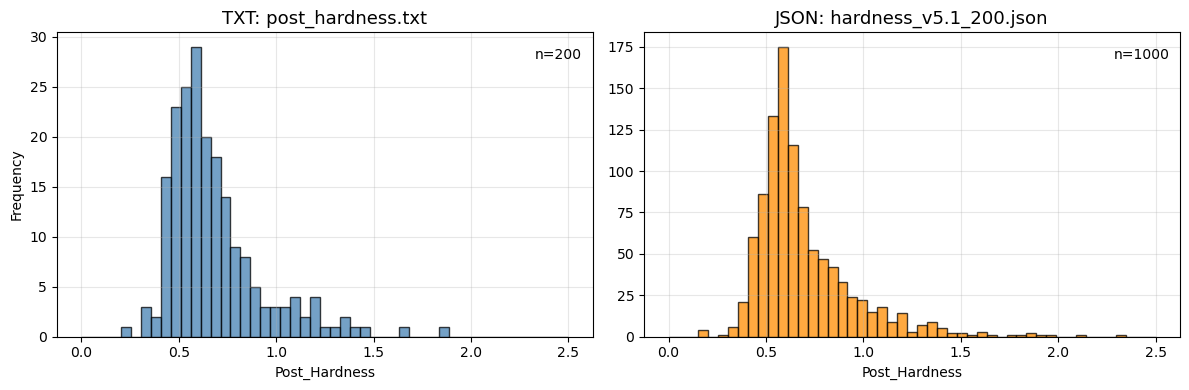

[Output] Saved → /home/ec2-user/hybrid_hardness/fidelity_experiment/yfcc_generated/mid_format/hardness_comparison.png

====================== SUMMARY STATISTICS ======================
                 TXT (post_hardness.txt)
     count : 200.000000
      mean : 0.682647
       std : 0.243547
       min : 0.209332
       25% : 0.523145
    median : 0.616278
       75% : 0.761506
       max : 1.847307
       iqr : 0.238361

                 JSON (hardness_v5.1_200.json)
     count : 1000.000000
      mean : 0.699758
       std : 0.303384
       min : 0.176210
       25% : 0.541816
    median : 0.616057
       75% : 0.781580
       max : 4.946994
       iqr : 0.239764

==================== DIFFERENCE (TXT - JSON) ====================
     count : -800.000000
      mean : -0.017110
       std : -0.059837
       min : 0.033122
       25% : -0.018671
    median : 0.000220
       75% : -0.020074
       max : -3.099687
       iqr : -0.001403


In [40]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os

# -------------------------------------------------
# 경로 설정
# -------------------------------------------------
txt_path = "/home/ec2-user/hybrid_hardness/fidelity_experiment/yfcc_generated/mid_format/post_hardness.txt"
json_path = "/home/ec2-user/hybrid_hardness/semi-real/filterbenchmark/yfcc/hardness/hardness_v5.1_1000.json"

# -------------------------------------------------
# 1) TXT hardness 로딩
# -------------------------------------------------
if not os.path.exists(txt_path):
    raise FileNotFoundError(txt_path)

vals_txt = np.loadtxt(txt_path, dtype=float)
vals_txt = vals_txt[np.isfinite(vals_txt)]  # 방어적 필터

# -------------------------------------------------
# 2) JSON hardness 로딩
# -------------------------------------------------
if not os.path.exists(json_path):
    raise FileNotFoundError(json_path)

with open(json_path, "r", encoding="utf-8") as f:
    data_json = json.load(f)

vals_json = np.array([item["Post_Hardness"] for item in data_json], dtype=float)

# -------------------------------------------------
# 3) 통계 계산 함수
# -------------------------------------------------
def get_stats(arr):
    return {
        "count": len(arr),
        "mean": np.mean(arr),
        "std": np.std(arr),
        "min": np.min(arr),
        "25%": np.percentile(arr, 25),
        "median": np.median(arr),
        "75%": np.percentile(arr, 75),
        "max": np.max(arr),
        "iqr": np.percentile(arr, 75) - np.percentile(arr, 25)
    }

stats_txt = get_stats(vals_txt)
stats_json = get_stats(vals_json)

# -------------------------------------------------
# 4) 플롯 준비
# -------------------------------------------------
plt.figure(figsize=(12, 4))

global_min = min(vals_txt.min(), vals_json.min())
global_max = max(vals_txt.max(), vals_json.max())
bin_edges = np.linspace(0.0, 2.5, 50)


# Subplot 1: TXT
ax1 = plt.subplot(1, 2, 1)
ax1.hist(vals_txt, bins=bin_edges, color="steelblue", edgecolor="black", alpha=0.75)
ax1.set_title("TXT: post_hardness.txt", fontsize=13)
ax1.set_xlabel("Post_Hardness")
ax1.set_ylabel("Frequency")
ax1.grid(alpha=0.3)
ax1.text(0.98, 0.95, f"n={len(vals_txt)}", ha="right", va="top", transform=ax1.transAxes)

# Subplot 2: JSON
ax2 = plt.subplot(1, 2, 2)
ax2.hist(vals_json, bins=bin_edges, color="darkorange", edgecolor="black", alpha=0.75)
ax2.set_title("JSON: hardness_v5.1_200.json", fontsize=13)
ax2.set_xlabel("Post_Hardness")
ax2.grid(alpha=0.3)
ax2.text(0.98, 0.95, f"n={len(vals_json)}", ha="right", va="top", transform=ax2.transAxes)

plt.tight_layout()

# Save
save_path = os.path.join(os.path.dirname(txt_path), "hardness_comparison.png")
plt.savefig(save_path, dpi=150)
plt.show()

print(f"[Output] Saved → {save_path}")

# -------------------------------------------------
# 5) 통계 비교 출력
# -------------------------------------------------
print("\n====================== SUMMARY STATISTICS ======================")
print("                 TXT (post_hardness.txt)")
for k, v in stats_txt.items():
    print(f"  {k:>8} : {v:.6f}")

print("\n                 JSON (hardness_v5.1_200.json)")
for k, v in stats_json.items():
    print(f"  {k:>8} : {v:.6f}")

print("\n==================== DIFFERENCE (TXT - JSON) ====================")
for k in stats_txt.keys():
    diff = stats_txt[k] - stats_json[k]
    print(f"  {k:>8} : {diff:.6f}")


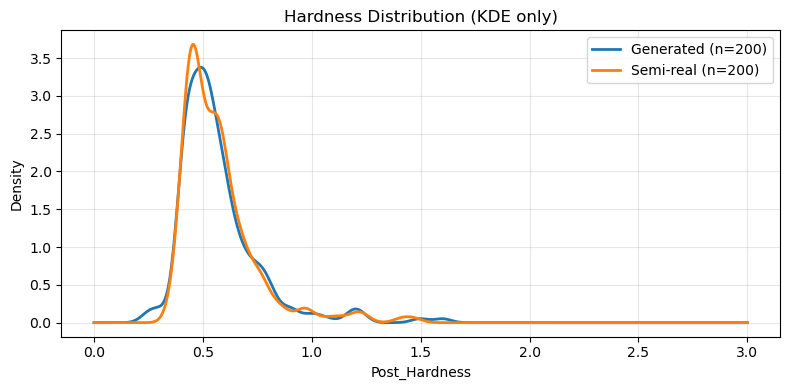

[Saved] /home/ec2-user/hybrid_hardness/fidelity_experiment/arxiv_generated_4/mid_format/hardness_kde.png


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os

# -------------------------------------------------
# 경로 설정
# -------------------------------------------------
txt_path = "/home/ec2-user/hybrid_hardness/fidelity_experiment/arxiv_generated_4/mid_format/post_hardness.txt"
json_path = "/home/ec2-user/hybrid_hardness/semi-real/filterbenchmark/arxiv/hardness/hardness_v5.1_200.json"

# -------------------------------------------------
# Plot 옵션
# -------------------------------------------------
FIX_X_RANGE = True
X_MIN, X_MAX = 0.0, 3.0
KDE_GRID = 500

# -------------------------------------------------
# 데이터 로딩
# -------------------------------------------------
vals_txt = np.loadtxt(txt_path, dtype=float)
vals_txt = vals_txt[np.isfinite(vals_txt)]

with open(json_path, "r", encoding="utf-8") as f:
    data_json = json.load(f)
vals_json = np.array([d["Post_Hardness"] for d in data_json], dtype=float)
vals_json = vals_json[np.isfinite(vals_json)]

# -------------------------------------------------
# KDE 구현 (scipy 없이)
# -------------------------------------------------
def silverman_bw(x):
    n = len(x)
    std = np.std(x, ddof=1)
    iqr = np.percentile(x, 75) - np.percentile(x, 25)
    sigma = min(std, iqr / 1.349) if iqr > 0 else std
    return 0.9 * sigma * (n ** (-1 / 5))

def kde_1d(x, grid, bw):
    diff = (grid[:, None] - x[None, :]) / bw
    return np.exp(-0.5 * diff**2).mean(axis=1) / (bw * np.sqrt(2 * np.pi))

# -------------------------------------------------
# Grid
# -------------------------------------------------
x_min = X_MIN if FIX_X_RANGE else min(vals_txt.min(), vals_json.min())
x_max = X_MAX if FIX_X_RANGE else max(vals_txt.max(), vals_json.max())
grid = np.linspace(x_min, x_max, KDE_GRID)

# KDE 계산
bw_txt = silverman_bw(vals_txt)
bw_json = silverman_bw(vals_json)

kde_txt = kde_1d(vals_txt, grid, bw_txt)
kde_json = kde_1d(vals_json, grid, bw_json)

# -------------------------------------------------
# Plot (KDE only)
# -------------------------------------------------
plt.figure(figsize=(8, 4))

plt.plot(grid, kde_txt, label=f"Generated (n={len(vals_txt)})", linewidth=2)
plt.plot(grid, kde_json, label=f"Semi-real (n={len(vals_json)})", linewidth=2)

plt.xlabel("Post_Hardness")
plt.ylabel("Density")
plt.title("Hardness Distribution (KDE only)")
plt.legend()
plt.grid(alpha=0.3)

out_path = os.path.join(os.path.dirname(txt_path), "hardness_kde.png")
plt.tight_layout()
# plt.savefig(out_path, dpi=150)
plt.show()

print(f"[Saved] {out_path}")


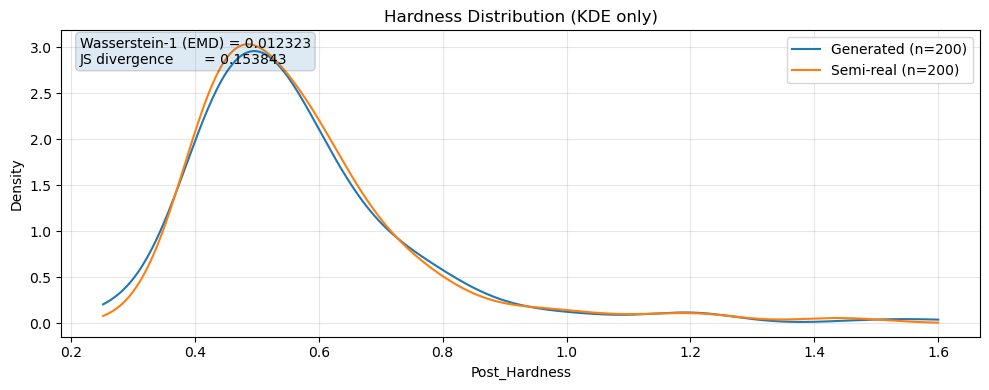

[Output] Saved → /home/ec2-user/hybrid_hardness/fidelity_experiment/arxiv_generated_4/mid_format/hardness_kde_with_metrics.png

====================== SUMMARY STATISTICS ======================
                 TXT (generated post_hardness.txt)
     count : 200
      mean : 0.571839
       std : 0.190623
       min : 0.251701
       25% : 0.454429
    median : 0.526979
       75% : 0.622202
       max : 1.600361
       iqr : 0.167774

                 JSON (semi-real hardness_v5.1_200.json)
     count : 200
      mean : 0.574522
       std : 0.180662
       min : 0.360121
       25% : 0.454761
    median : 0.533634
       75% : 0.621032
       max : 1.468954
       iqr : 0.166271

==================== DISTANCE METRICS ====================
  Wasserstein-1 (EMD) : 0.012323   (smaller = closer)
  JS divergence       : 0.153843   (0 = identical; <= ln(2) ~ 0.693)

==================== DIFFERENCE (TXT - JSON) ====================
     count : 0
      mean : -0.002683
       std : 0.009961
  

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os

# -------------------------------------------------
# 경로 설정
# -------------------------------------------------
txt_path = "/home/ec2-user/hybrid_hardness/fidelity_experiment/arxiv_generated_4/mid_format/post_hardness.txt"
json_path = "/home/ec2-user/hybrid_hardness/semi-real/filterbenchmark/arxiv/hardness/hardness_v5.1_200.json"

# -------------------------------------------------
# 1) 데이터 로딩
# -------------------------------------------------
if not os.path.exists(txt_path):
    raise FileNotFoundError(txt_path)
if not os.path.exists(json_path):
    raise FileNotFoundError(json_path)

vals_txt = np.loadtxt(txt_path, dtype=float)
vals_txt = vals_txt[np.isfinite(vals_txt)]

with open(json_path, "r", encoding="utf-8") as f:
    data_json = json.load(f)

vals_json = np.array([item["Post_Hardness"] for item in data_json], dtype=float)
vals_json = vals_json[np.isfinite(vals_json)]

if len(vals_txt) == 0 or len(vals_json) == 0:
    raise RuntimeError("Empty hardness arrays after filtering non-finite values.")

# -------------------------------------------------
# 2) 통계 함수
# -------------------------------------------------
def get_stats(arr):
    arr = np.asarray(arr, dtype=float)
    return {
        "count": int(len(arr)),
        "mean": float(np.mean(arr)),
        "std": float(np.std(arr)),
        "min": float(np.min(arr)),
        "25%": float(np.percentile(arr, 25)),
        "median": float(np.median(arr)),
        "75%": float(np.percentile(arr, 75)),
        "max": float(np.max(arr)),
        "iqr": float(np.percentile(arr, 75) - np.percentile(arr, 25)),
    }

# -------------------------------------------------
# 3) Wasserstein-1 (EMD) 계산 (경험분포, bin 없이)
#    W1 = ∫ |F(x) - G(x)| dx
# -------------------------------------------------
def wasserstein_1d_empirical(x, y):
    x = np.sort(np.asarray(x, dtype=float))
    y = np.sort(np.asarray(y, dtype=float))

    # 모든 변화점(샘플 값)을 합친 그리드
    z = np.sort(np.unique(np.concatenate([x, y])))

    # 각 z에서의 경험적 CDF 값
    Fx = np.searchsorted(x, z, side="right") / x.size
    Fy = np.searchsorted(y, z, side="right") / y.size

    # 구간별 적분: |F-G|는 각 구간에서 상수(우측연속 step)라서
    # 단순히 |F(z_i)-G(z_i)| * (z_{i+1}-z_i)로 근사(정확히는 step 기준)
    dz = np.diff(z)
    if dz.size == 0:
        return 0.0

    integrand = np.abs(Fx[:-1] - Fy[:-1])
    return float(np.sum(integrand * dz))

# -------------------------------------------------
# 4) JS divergence 계산 (bin 기반, 0~ln2)
#    JS(P||Q) = 0.5*KL(P||M) + 0.5*KL(Q||M), M=(P+Q)/2
# -------------------------------------------------
def jensen_shannon_divergence(x, y, num_bins=200, bin_range=None, eps=1e-12):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if bin_range is None:
        lo = float(min(x.min(), y.min()))
        hi = float(max(x.max(), y.max()))
    else:
        lo, hi = float(bin_range[0]), float(bin_range[1])

    # 동일 bin에서 확률질량함수(PMF) 생성
    edges = np.linspace(lo, hi, num_bins + 1)
    hx, _ = np.histogram(x, bins=edges, density=False)
    hy, _ = np.histogram(y, bins=edges, density=False)

    px = hx.astype(float)
    py = hy.astype(float)

    # 정규화(합=1). 0 방지용 eps 추가
    px = px / max(px.sum(), 1.0)
    py = py / max(py.sum(), 1.0)

    px = np.clip(px, eps, 1.0)
    py = np.clip(py, eps, 1.0)

    px = px / px.sum()
    py = py / py.sum()

    m = 0.5 * (px + py)

    def kl(p, q):
        return float(np.sum(p * np.log(p / q)))

    js = 0.5 * kl(px, m) + 0.5 * kl(py, m)
    return js

# -------------------------------------------------
# 5) KDE 계산(가우시안 커널)
#    - scipy 없이 구현 (bandwidth: Silverman rule)
# -------------------------------------------------
def kde_gaussian_1d(samples, grid, bandwidth=None):
    x = np.asarray(samples, dtype=float)
    n = x.size
    if n < 2:
        return np.zeros_like(grid, dtype=float)

    std = np.std(x, ddof=1)
    if bandwidth is None:
        # Silverman
        bw = 1.06 * std * (n ** (-1 / 5))
        if not np.isfinite(bw) or bw <= 0:
            bw = 1e-3
    else:
        bw = float(bandwidth)

    # KDE: 평균 of Gaussian kernels
    # density(g) = (1/(n*bw)) * sum phi((g-x_i)/bw)
    diff = (grid[:, None] - x[None, :]) / bw
    dens = np.mean(np.exp(-0.5 * diff * diff), axis=1) / (bw * np.sqrt(2 * np.pi))
    return dens

# -------------------------------------------------
# 6) 메트릭 계산
# -------------------------------------------------
w1 = wasserstein_1d_empirical(vals_txt, vals_json)

# JS는 bin 필요. (여기서는 KDE 그림 x축 범위와도 맞추기 위해 global range 사용)
global_min = float(min(vals_txt.min(), vals_json.min()))
global_max = float(max(vals_txt.max(), vals_json.max()))
js = jensen_shannon_divergence(vals_txt, vals_json, num_bins=200, bin_range=(global_min, global_max))

stats_txt = get_stats(vals_txt)
stats_json = get_stats(vals_json)

# -------------------------------------------------
# 7) KDE Plot (히스토그램 없음)
# -------------------------------------------------
# (원하면 범위를 넉넉히 잡아도 됨. 지금은 데이터 기반)
x_grid = np.linspace(global_min, global_max, 600)

kde_txt = kde_gaussian_1d(vals_txt, x_grid)
kde_json = kde_gaussian_1d(vals_json, x_grid)

plt.figure(figsize=(10, 4))
plt.plot(x_grid, kde_txt, label=f"Generated (n={len(vals_txt)})")
plt.plot(x_grid, kde_json, label=f"Semi-real (n={len(vals_json)})")

plt.title("Hardness Distribution (KDE only)")
plt.xlabel("Post_Hardness")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.legend(loc="best")

# 메트릭을 그림 안에 표시
txt_metrics = (
    f"Wasserstein-1 (EMD) = {w1:.6f}\n"
    f"JS divergence       = {js:.6f}"
)
plt.text(
    0.02, 0.98, txt_metrics,
    transform=plt.gca().transAxes,
    ha="left", va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.tight_layout()

save_path = os.path.join(os.path.dirname(txt_path), "hardness_kde_with_metrics.png")
plt.savefig(save_path, dpi=150)
plt.show()

print(f"[Output] Saved → {save_path}")

# -------------------------------------------------
# 8) 통계 출력 + 메트릭 출력
# -------------------------------------------------
print("\n====================== SUMMARY STATISTICS ======================")
print("                 TXT (generated post_hardness.txt)")
for k, v in stats_txt.items():
    if k == "count":
        print(f"  {k:>8} : {v:d}")
    else:
        print(f"  {k:>8} : {v:.6f}")

print("\n                 JSON (semi-real hardness_v5.1_200.json)")
for k, v in stats_json.items():
    if k == "count":
        print(f"  {k:>8} : {v:d}")
    else:
        print(f"  {k:>8} : {v:.6f}")

print("\n==================== DISTANCE METRICS ====================")
print(f"  Wasserstein-1 (EMD) : {w1:.6f}   (smaller = closer)")
print(f"  JS divergence       : {js:.6f}   (0 = identical; <= ln(2) ~ 0.693)")

print("\n==================== DIFFERENCE (TXT - JSON) ====================")
for k in stats_txt.keys():
    if k == "count":
        diff = stats_txt[k] - stats_json[k]
        print(f"  {k:>8} : {diff:d}")
    else:
        diff = stats_txt[k] - stats_json[k]
        print(f"  {k:>8} : {diff:.6f}")


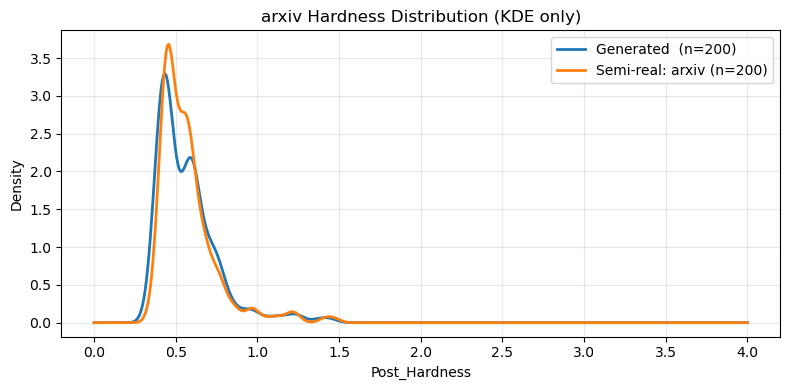

[Saved] /home/ec2-user/hybrid_hardness/fidelity_experiment/arxiv_generated_wo_payload/mid_format/hardness_kde.png


In [ ]:
semi_real_dataset_name = "arxiv"
num_query_original = 200



import numpy as np
import matplotlib.pyplot as plt
import json
import os

# -------------------------------------------------
# 경로 설정
# -------------------------------------------------
txt_path = f"/home/ec2-user/hybrid_hardness/fidelity_experiment/{semi_real_dataset_name}_generated/mid_format/post_hardness.txt"
json_path = f"/home/ec2-user/hybrid_hardness/semi-real/filterbenchmark/{semi_real_dataset_name}/hardness/hardness_v5.1_{num_query_original}.json"

# -------------------------------------------------
# Plot 옵션
# -------------------------------------------------
FIX_X_RANGE = True
X_MIN, X_MAX = 0.0, 4.0
KDE_GRID = 500

# -------------------------------------------------
# 데이터 로딩
# -------------------------------------------------
vals_txt = np.loadtxt(txt_path, dtype=float)
vals_txt = vals_txt[np.isfinite(vals_txt)]

with open(json_path, "r", encoding="utf-8") as f:
    data_json = json.load(f)
vals_json = np.array([d["Post_Hardness"] for d in data_json], dtype=float)
vals_json = vals_json[np.isfinite(vals_json)]

# -------------------------------------------------
# KDE 구현 (scipy 없이)
# -------------------------------------------------
def silverman_bw(x):
    n = len(x)
    std = np.std(x, ddof=1)
    iqr = np.percentile(x, 75) - np.percentile(x, 25)
    sigma = min(std, iqr / 1.349) if iqr > 0 else std
    return 0.9 * sigma * (n ** (-1 / 5))

def kde_1d(x, grid, bw):
    diff = (grid[:, None] - x[None, :]) / bw
    return np.exp(-0.5 * diff**2).mean(axis=1) / (bw * np.sqrt(2 * np.pi))

# -------------------------------------------------
# Grid
# -------------------------------------------------
x_min = X_MIN if FIX_X_RANGE else min(vals_txt.min(), vals_json.min())
x_max = X_MAX if FIX_X_RANGE else max(vals_txt.max(), vals_json.max())
grid = np.linspace(x_min, x_max, KDE_GRID)

# KDE 계산
bw_txt = silverman_bw(vals_txt)
bw_json = silverman_bw(vals_json)

kde_txt = kde_1d(vals_txt, grid, bw_txt)
kde_json = kde_1d(vals_json, grid, bw_json)

# -------------------------------------------------
# Plot (KDE only)
# -------------------------------------------------
plt.figure(figsize=(8, 4))

plt.plot(grid, kde_txt, label=f"Generated  (n={len(vals_txt)})", linewidth=2)
plt.plot(grid, kde_json, label=f"Semi-real: {semi_real_dataset_name} (n={len(vals_json)})", linewidth=2)

plt.xlabel("Post_Hardness")
plt.ylabel("Density")
plt.title(f"{semi_real_dataset_name} Hardness Distribution (KDE only)")
plt.legend()
plt.grid(alpha=0.3)

out_path = os.path.join(os.path.dirname(txt_path), "hardness_kde.png")
plt.tight_layout()
# plt.savefig(out_path, dpi=150)
plt.show()

print(f"[Saved] {out_path}")
